### Region masking GAINS emissions for HTAP3OPNS

In [1]:
import xarray as xr
import numpy as np
import glob
import cartopy.crs as ccrs
import cartopy
import matplotlib.pyplot as plt


### Import data and regions file

In [2]:
xr.set_options(keep_attrs=True)

In [3]:
#file locations
file_loc_mask = '/div/no-backup-nac/users/zofias/GAINS'
file_loc_gains = '/div/no-backup-nac/users/zofias/GAINS'

file_outdir = '/div/no-backup-nac/users/zofias/GAINS/regions/'

In [4]:
#filenames
gains_file = 'LRTAP_Baseline_v5_OC_2015_CTM.nc'

In [8]:
filelist = glob.glob(f'{file_loc_gains}/*CTM*.nc')

In [6]:
#import region mask data
regions_data = xr.open_dataset(f'{file_loc_mask}/HTAP3_Regions_NC01x01_v3.nc')

# make boolean region masks for each region
EAS_mask = regions_data.EAS > 0.9
EMEP_mask = regions_data.EMEP > 0.9
SAS_mask = regions_data.SAS > 0.9
SMD_mask = regions_data.SMD > 0.9
NAM_mask = regions_data.NAM > 0.9

## Test with one file

In [7]:
test_file = xr.open_dataset(filelist[0])

In [27]:
test_file

<xarray.Dataset>
Dimensions:      (time: 12, lat: 1800, lon: 3600)
Coordinates:
  * lat          (lat) float64 -89.95 -89.85 -89.75 -89.65 ... 89.75 89.85 89.95
  * lon          (lon) float64 -179.9 -179.8 -179.8 -179.7 ... 179.8 179.8 179.9
    spatial_ref  int32 ...
  * time         (time) datetime64[ns] 2015-01-01 2015-02-01 ... 2015-12-01
Data variables:
    ENE          (time, lat, lon) float64 ...
    IND          (time, lat, lon) float64 ...
    TRA          (time, lat, lon) float64 ...
    RCO          (time, lat, lon) float64 ...
    WAS          (time, lat, lon) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SHI          (time, lat, lon) float64 ...
    AWB          (time, lat, lon) float64 ...
Attributes:
    description:   Gridded emissions of OC by FORCeS sector
    scenario:      LRTAP_Baseline_v5
    generated_by:  Florian Lindl, IIASA
    date:          2024-11-21 00:00:00
    NCO:           netCDF Operators version 5.3.4 (Homepage = http://nco.sf.n...
    history:       Wed Aug 20 12:50:36 2025: ncpdq -a time,lat,lon /cluster/p...

In [8]:
regions_data

<xarray.Dataset>
Dimensions:    (lat: 1800, lon: 3600, bnds: 2)
Coordinates:
  * lat        (lat) float64 -89.95 -89.85 -89.75 -89.65 ... 89.75 89.85 89.95
  * lon        (lon) float64 -179.9 -179.8 -179.8 -179.7 ... 179.8 179.9 180.0
Dimensions without coordinates: bnds
Data variables: (12/17)
    EAS        (lat, lon) int8 ...
    EMEP       (lat, lon) int8 ...
    MCA        (lat, lon) int8 ...
    MDE        (lat, lon) int8 ...
    NAF        (lat, lon) int8 ...
    NAM        (lat, lon) int8 ...
    ...         ...
    SMD        (lat, lon) int8 ...
    ROW        (lat, lon) int8 ...
    EMEP_East  (lat, lon) int8 ...
    EMEP_West  (lat, lon) int8 ...
    lat_bnds   (lat, bnds) float64 ...
    lon_bnds   (lon, bnds) float64 ...
Attributes:
    history:  Mon May 19 10:45:10 CEST 2025: Tim Butler (tim.butler@rifs-pots...
    version:  v3

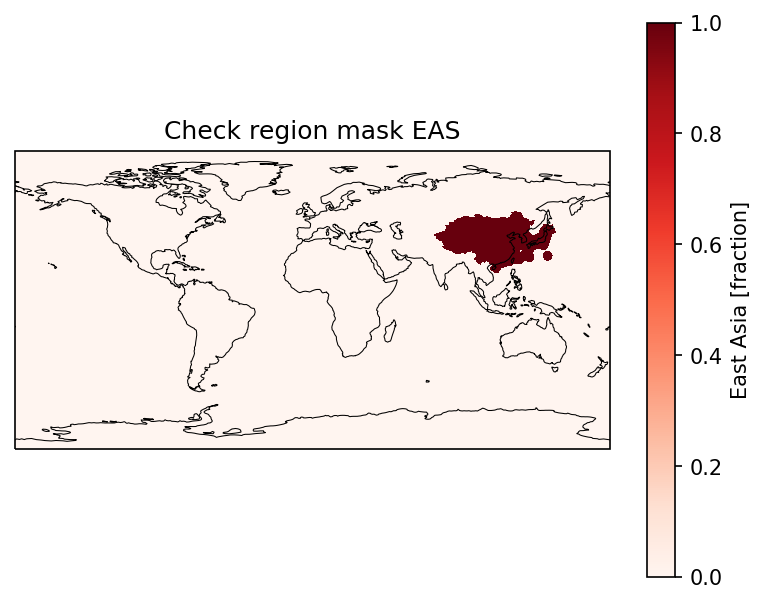

In [ ]:
#see what mask looks like
fig, axis = plt.subplots(1, 1, dpi=150, subplot_kw=dict(projection=ccrs.PlateCarree()))
regions_data['EAS'].plot(cmap='Reds')

plt.title(f"Check region mask EAS")
axis.coastlines(linewidth=0.5)  # cartopy function


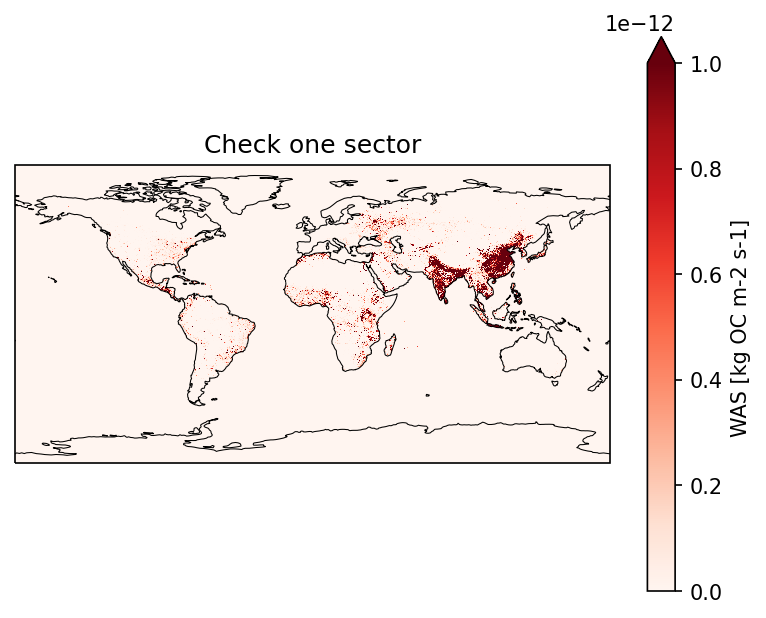

In [ ]:
#check one sector
fig, axis = plt.subplots(1, 1, dpi=150, subplot_kw=dict(projection=ccrs.PlateCarree()))
test_file['WAS'].mean(dim='time').plot(cmap='Reds',vmax=1e-12)

plt.title(f"Check one sector")
axis.coastlines(linewidth=0.5)  # cartopy function

In [18]:
test_EAS = test_file.where(EAS_mask)

In [29]:
test_EAS.to_netcdf('/div/no-backup-nac/users/zofias/GAINS/LRTAP_Baseline_v5_OC_2015_CTM_EAS.nc')

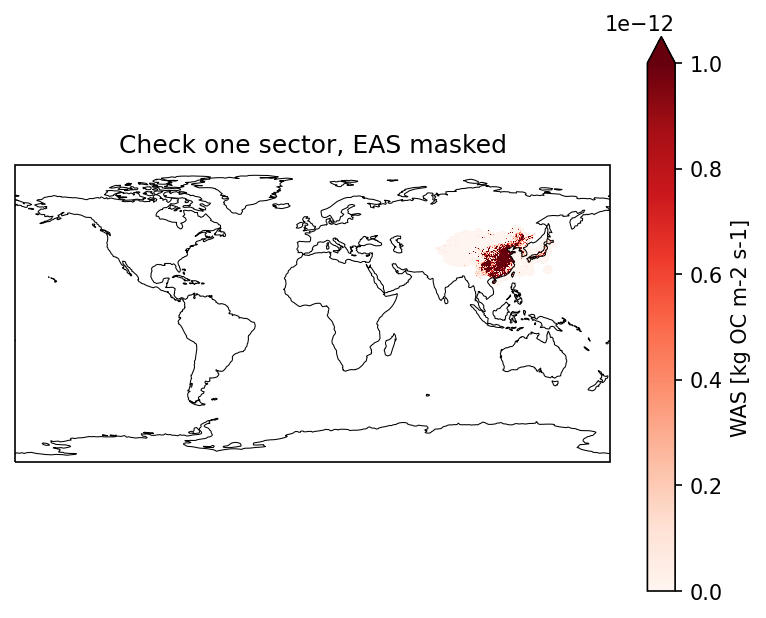

In [26]:
#check one sector
fig, axis = plt.subplots(1, 1, dpi=150, subplot_kw=dict(projection=ccrs.PlateCarree()))
test_EAS['WAS'].mean(dim='time').plot(cmap='Reds',vmax=1e-12)

plt.title(f"Check one sector, EAS masked")
axis.coastlines(linewidth=0.5)  # cartopy function

### Apply region masks to all species

In [ ]:
for file in filelist:
    #import GAINS data, get label
    filename = file.split(sep='/')[-1]
    file_lab = filename[:-3]
    print(f'Processing {file_lab}')

    #open file
    data = xr.open_dataset(file)

    #region masking and save to netcdf
    EAS = data.where(EAS_mask)
    EAS.to_netcdf(f'{file_outdir}{file_lab}_EAS.nc')
    print('EAS done')

    NAM = data.where(NAM_mask)
    NAM.to_netcdf(f'{file_outdir}{file_lab}_NAM.nc')
    print('NAM done')

    SMD = data.where(SMD_mask)
    SMD.to_netcdf(f'{file_outdir}{file_lab}_SMD.nc')
    print('SMD done')

    EMEP = data.where(EMEP_mask)
    EMEP.to_netcdf(f'{file_outdir}{file_lab}_EMEP.nc')
    print('EMEP done')

    SAS = data.where(SAS_mask)
    SAS.to_netcdf(f'{file_outdir}{file_lab}_SAS.nc')
    print('SAS done')


Processing LRTAP_Baseline_v5_OC_2015_CTM
Processing LRTAP_Baseline_v5_OC_2040_CTM
Processing LRTAP_MTFR_v5a_OC_2040_CTM
Processing LRTAP_Baseline_v5_BC_2015_CTM
Processing LRTAP_Baseline_v5_BC_2040_CTM
Processing LRTAP_MTFR_v5a_BC_2040_CTM
Processing LRTAP_Baseline_v5_BC_2040_CTM_fossil
Processing LRTAP_MTFR_v5a_BC_2040_CTM_fossil
Processing LRTAP_Baseline_v5_OC_2015_CTM_solid_biofuel
Processing LRTAP_Baseline_v5_OC_2015_CTM_fossil
Processing LRTAP_Baseline_v5_OC_2040_CTM_solid_biofuel
Processing LRTAP_Baseline_v5_OC_2040_CTM_fossil
Processing LRTAP_MTFR_v5a_OC_2040_CTM_solid_biofuel
Processing LRTAP_MTFR_v5a_OC_2040_CTM_fossil
Processing LRTAP_Baseline_v5_BC_2015_CTM_solid_biofuel
Processing LRTAP_Baseline_v5_BC_2015_CTM_fossil
Processing LRTAP_Baseline_v5_BC_2040_CTM_solid_biofuel
Processing LRTAP_MTFR_v5a_BC_2040_CTM_solid_biofuel
